In [2]:
import pandas as pd

asset_metadata = pd.read_csv("C:/Users/infantshubiksha.john/OneDrive - Everrenew Energy Private Limited/Documents/Necter_assesment/asset_metadata.csv")
connectivity = pd.read_csv("C:/Users/infantshubiksha.john/OneDrive - Everrenew Energy Private Limited/Documents/Necter_assesment/connectivity.csv")

print("ASSET METADATA SHAPE:")
print(asset_metadata.shape)

print("\nASSET METADATA COLUMNS:")
print(asset_metadata.columns.tolist())

print("\nASSET METADATA SAMPLE:")
print(asset_metadata.head())

print("\n" + "="*80)

print("\nCONNECTIVITY SHAPE:")
print(connectivity.shape)

print("\nCONNECTIVITY COLUMNS:")
print(connectivity.columns.tolist())

print("\nCONNECTIVITY SAMPLE:")
print(connectivity.head())

ASSET METADATA SHAPE:
(42, 8)

ASSET METADATA COLUMNS:
['asset_id', 'site_id', 'asset_name', 'asset_type', 'manufacturer', 'installation_date', 'capacity', 'parent_asset_id']

ASSET METADATA SAMPLE:
        asset_id site_id     asset_name asset_type     manufacturer  \
0       B1_CH_01      S1       B1_CH_01    Chiller        Schneider   
1      B1_AHU_01      S1      B1_AHU_01        AHU  JohnsonControls   
2  B1_AHU_01_SEN      S1  B1_AHU_01_SEN     Sensor          Siemens   
3      B1_AHU_02      S1      B1_AHU_02        AHU        Schneider   
4  B1_AHU_02_SEN      S1  B1_AHU_02_SEN     Sensor        Schneider   

  installation_date  capacity parent_asset_id  
0        2021-01-01       500             NaN  
1        2022-01-01       150        B1_CH_01  
2        2023-01-01        10       B1_AHU_01  
3        2022-01-01       150        B1_CH_01  
4        2023-01-01        10       B1_AHU_02  


CONNECTIVITY SHAPE:
(36, 4)

CONNECTIVITY COLUMNS:
['source_asset_id', 'target_asset

In [3]:
#Data quality assetment
# Missing values

print("Asset Metadata Missing Values")
print(asset_metadata.isnull().sum())

print("\nConnectivity Missing Values")
print(connectivity.isnull().sum())

Asset Metadata Missing Values
asset_id             0
site_id              0
asset_name           0
asset_type           0
manufacturer         0
installation_date    0
capacity             0
parent_asset_id      6
dtype: int64

Connectivity Missing Values
source_asset_id          0
target_asset_id          0
connection_type          0
relationship_strength    0
dtype: int64


In [4]:
# Duplicate assets

print(
    "Duplicate Asset IDs:",
    asset_metadata["asset_id"].duplicated().sum()
)

# Duplicate connections

print(
    "Duplicate Connections:",
    connectivity.duplicated().sum()
)

Duplicate Asset IDs: 0
Duplicate Connections: 0


In [5]:
# Orphan assets
# Assets that have no parent

orphan_assets = asset_metadata[
    asset_metadata["parent_asset_id"].isna()
]

print(
    "Number of Top-Level/Orphan Assets:",
    len(orphan_assets)
)

orphan_assets[
    [
        "asset_id",
        "asset_type"
    ]
]

Number of Top-Level/Orphan Assets: 6


,asset_id,asset_type
0,B1_CH_01,Chiller
7,B2_CH_01,Chiller
14,B3_CH_01,Chiller
21,B4_CH_01,Chiller
28,B5_CH_01,Chiller
35,B6_CH_01,Chiller


In [6]:
# Invalid parent mappings

valid_assets = set(
    asset_metadata["asset_id"]
)

invalid_parents = asset_metadata[
    (
        asset_metadata["parent_asset_id"].notna()
    )
    &
    (
        ~asset_metadata["parent_asset_id"]
        .isin(valid_assets)
    )
]

print(
    "Invalid Parent Mappings:",
    len(invalid_parents)
)

invalid_parents

Invalid Parent Mappings: 0


,asset_id,site_id,asset_name,asset_type,manufacturer,installation_date,capacity,parent_asset_id


In [7]:
#Asset hierarchy analyse
print(
    asset_metadata[
        [
            "site_id",
            "asset_id",
            "asset_type",
            "parent_asset_id"
        ]
    ]
    .head(20)
)

   site_id       asset_id   asset_type parent_asset_id
0       S1       B1_CH_01      Chiller             NaN
1       S1      B1_AHU_01          AHU        B1_CH_01
2       S1  B1_AHU_01_SEN       Sensor       B1_AHU_01
3       S1      B1_AHU_02          AHU        B1_CH_01
4       S1  B1_AHU_02_SEN       Sensor       B1_AHU_02
5       S1     B1_PUMP_01         Pump        B1_CH_01
6       S1    B1_METER_01  EnergyMeter      B1_PUMP_01
7       S1       B2_CH_01      Chiller             NaN
8       S1      B2_AHU_01          AHU        B2_CH_01
9       S1  B2_AHU_01_SEN       Sensor       B2_AHU_01
10      S1      B2_AHU_02          AHU        B2_CH_01
11      S1  B2_AHU_02_SEN       Sensor       B2_AHU_02
12      S1     B2_PUMP_01         Pump        B2_CH_01
13      S1    B2_METER_01  EnergyMeter      B2_PUMP_01
14      S2       B3_CH_01      Chiller             NaN
15      S2      B3_AHU_01          AHU        B3_CH_01
16      S2  B3_AHU_01_SEN       Sensor       B3_AHU_01
17      S2

In [8]:
asset_type_summary = (
    asset_metadata["asset_type"]
    .value_counts()
    .reset_index()
)

asset_type_summary.columns = [
    "Asset Type",
    "Count"
]

asset_type_summary

,Asset Type,Count
0,AHU,12
1,Sensor,12
2,Chiller,6
3,Pump,6
4,EnergyMeter,6


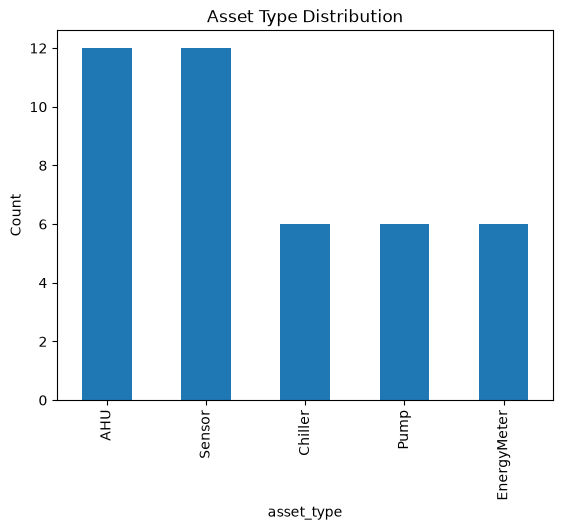

In [9]:
import matplotlib.pyplot as plt

asset_metadata["asset_type"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Asset Type Distribution"
)

plt.ylabel(
    "Count"
)

plt.show()

In [10]:
#connectivity analysis
print("Number of Connections:")
print(len(connectivity))

print("\nConnection Types:")
print(
    connectivity["connection_type"]
    .value_counts()
)

Number of Connections:
36

Connection Types:
connection_type
Monitors    18
Supplies    12
Controls     6
Name: count, dtype: int64


In [11]:
strong_connections = (
    connectivity
    .sort_values(
        "relationship_strength",
        ascending=False
    )
)

strong_connections.head(15)

,source_asset_id,target_asset_id,connection_type,relationship_strength
0,B1_CH_01,B1_AHU_01,Supplies,0.90
2,B1_CH_01,B1_AHU_02,Supplies,0.90
8,B2_CH_01,B2_AHU_02,Supplies,0.90
6,B2_CH_01,B2_AHU_01,Supplies,0.90
30,B6_CH_01,B6_AHU_01,Supplies,0.90
32,B6_CH_01,B6_AHU_02,Supplies,0.90
14,B3_CH_01,B3_AHU_02,Supplies,0.90
12,B3_CH_01,B3_AHU_01,Supplies,0.90
18,B4_CH_01,B4_AHU_01,Supplies,0.90
26,B5_CH_01,B5_AHU_02,Supplies,0.90


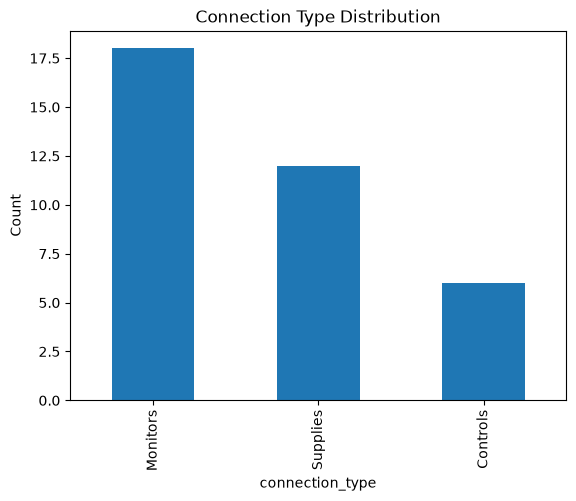

In [12]:
#connection type distribution plt
import matplotlib.pyplot as plt

connectivity[
    "connection_type"
].value_counts().plot(
    kind="bar"
)

plt.title(
    "Connection Type Distribution"
)

plt.ylabel(
    "Count"
)

plt.show()

In [13]:
#assets with most connections
outgoing_connections = (
    connectivity["source_asset_id"]
    .value_counts()
    .reset_index()
)

outgoing_connections.columns = [
    "Asset",
    "Number_of_Connections"
]

outgoing_connections.head(10)

,Asset,Number_of_Connections
0,B1_CH_01,3
1,B2_CH_01,3
2,B3_CH_01,3
3,B4_CH_01,3
4,B5_CH_01,3
5,B6_CH_01,3
6,B1_AHU_01,1
7,B1_AHU_02,1
8,B1_PUMP_01,1
9,B2_AHU_01,1


In [14]:
#assest dependency analysis

downstream_assets = (
    connectivity
    .groupby("source_asset_id")["target_asset_id"]
    .apply(list)
    .reset_index()
)

downstream_assets.columns = [
    "Asset",
    "Downstream_Assets"
]

print(downstream_assets)

         Asset                   Downstream_Assets
0    B1_AHU_01                     [B1_AHU_01_SEN]
1    B1_AHU_02                     [B1_AHU_02_SEN]
2     B1_CH_01  [B1_AHU_01, B1_AHU_02, B1_PUMP_01]
3   B1_PUMP_01                       [B1_METER_01]
4    B2_AHU_01                     [B2_AHU_01_SEN]
5    B2_AHU_02                     [B2_AHU_02_SEN]
6     B2_CH_01  [B2_AHU_01, B2_AHU_02, B2_PUMP_01]
7   B2_PUMP_01                       [B2_METER_01]
8    B3_AHU_01                     [B3_AHU_01_SEN]
9    B3_AHU_02                     [B3_AHU_02_SEN]
10    B3_CH_01  [B3_AHU_01, B3_AHU_02, B3_PUMP_01]
11  B3_PUMP_01                       [B3_METER_01]
12   B4_AHU_01                     [B4_AHU_01_SEN]
13   B4_AHU_02                     [B4_AHU_02_SEN]
14    B4_CH_01  [B4_AHU_01, B4_AHU_02, B4_PUMP_01]
15  B4_PUMP_01                       [B4_METER_01]
16   B5_AHU_01                     [B5_AHU_01_SEN]
17   B5_AHU_02                     [B5_AHU_02_SEN]
18    B5_CH_01  [B5_AHU_01, B5_

In [15]:
dependency_count = (
    connectivity
    .groupby("source_asset_id")["target_asset_id"]
    .nunique()
    .reset_index()
)

dependency_count.columns = [
    "Asset",
    "Downstream_Asset_Count"
]

dependency_count = dependency_count.sort_values(
    "Downstream_Asset_Count",
    ascending=False
)

dependency_count

,Asset,Downstream_Asset_Count
2,B1_CH_01,3
6,B2_CH_01,3
14,B4_CH_01,3
10,B3_CH_01,3
18,B5_CH_01,3
22,B6_CH_01,3
1,B1_AHU_02,1
0,B1_AHU_01,1
7,B2_PUMP_01,1
5,B2_AHU_02,1


In [16]:
#finding isolated assest
# All assets
all_assets = set(
    asset_metadata["asset_id"]
)

# Assets involved in connectivity
connected_assets = set(
    connectivity["source_asset_id"]
).union(
    set(connectivity["target_asset_id"])
)

# Isolated assets
isolated_assets = sorted(
    all_assets - connected_assets
)

print(
    "Number of isolated assets:",
    len(isolated_assets)
)

print("\nIsolated assets:")

print(isolated_assets)

Number of isolated assets: 0

Isolated assets:
[]


In [17]:
#parent child relationship
# Parent-child hierarchy

parent_child = asset_metadata[
    asset_metadata["parent_asset_id"].notna()
][
    [
        "parent_asset_id",
        "asset_id",
        "asset_type"
    ]
].sort_values(
    "parent_asset_id"
)

print(parent_child.to_string(index=False))

parent_asset_id      asset_id  asset_type
      B1_AHU_01 B1_AHU_01_SEN      Sensor
      B1_AHU_02 B1_AHU_02_SEN      Sensor
       B1_CH_01     B1_AHU_01         AHU
       B1_CH_01     B1_AHU_02         AHU
       B1_CH_01    B1_PUMP_01        Pump
     B1_PUMP_01   B1_METER_01 EnergyMeter
      B2_AHU_01 B2_AHU_01_SEN      Sensor
      B2_AHU_02 B2_AHU_02_SEN      Sensor
       B2_CH_01    B2_PUMP_01        Pump
       B2_CH_01     B2_AHU_02         AHU
       B2_CH_01     B2_AHU_01         AHU
     B2_PUMP_01   B2_METER_01 EnergyMeter
      B3_AHU_01 B3_AHU_01_SEN      Sensor
      B3_AHU_02 B3_AHU_02_SEN      Sensor
       B3_CH_01     B3_AHU_01         AHU
       B3_CH_01     B3_AHU_02         AHU
       B3_CH_01    B3_PUMP_01        Pump
     B3_PUMP_01   B3_METER_01 EnergyMeter
      B4_AHU_01 B4_AHU_01_SEN      Sensor
      B4_AHU_02 B4_AHU_02_SEN      Sensor
       B4_CH_01     B4_AHU_01         AHU
       B4_CH_01     B4_AHU_02         AHU
       B4_CH_01    B4_PUMP_01     

In [18]:
#failure impack analysis
import networkx as nx

G = nx.DiGraph()

# Add all assets as nodes
for asset in asset_metadata["asset_id"]:
    G.add_node(asset)

# Add connectivity relationships
for _, row in connectivity.iterrows():
    G.add_edge(
        row["source_asset_id"],
        row["target_asset_id"],
        connection_type=row["connection_type"],
        relationship_strength=row["relationship_strength"]
    )

print("Number of assets:", G.number_of_nodes())
print("Number of connections:", G.number_of_edges())

Number of assets: 42
Number of connections: 36


In [19]:
# downstream impact of failed asset
def get_downstream_impact(asset_id):

    if asset_id not in G:
        return []

    return list(
        nx.descendants(G, asset_id)
    )

In [20]:
chiller_assets = asset_metadata[
    asset_metadata["asset_type"].str.lower() == "chiller"
]["asset_id"].tolist()

print("Chiller assets:")
print(chiller_assets)

Chiller assets:
['B1_CH_01', 'B2_CH_01', 'B3_CH_01', 'B4_CH_01', 'B5_CH_01', 'B6_CH_01']


In [21]:
for chiller in chiller_assets:

    impacted = get_downstream_impact(chiller)

    print("\nFailed Asset:", chiller)
    print("Impacted downstream assets:", len(impacted))
    print(impacted)


Failed Asset: B1_CH_01
Impacted downstream assets: 6
['B1_AHU_02_SEN', 'B1_AHU_01', 'B1_METER_01', 'B1_PUMP_01', 'B1_AHU_02', 'B1_AHU_01_SEN']

Failed Asset: B2_CH_01
Impacted downstream assets: 6
['B2_AHU_01', 'B2_PUMP_01', 'B2_METER_01', 'B2_AHU_02', 'B2_AHU_02_SEN', 'B2_AHU_01_SEN']

Failed Asset: B3_CH_01
Impacted downstream assets: 6
['B3_AHU_01_SEN', 'B3_METER_01', 'B3_PUMP_01', 'B3_AHU_02_SEN', 'B3_AHU_01', 'B3_AHU_02']

Failed Asset: B4_CH_01
Impacted downstream assets: 6
['B4_AHU_02', 'B4_AHU_01_SEN', 'B4_PUMP_01', 'B4_METER_01', 'B4_AHU_02_SEN', 'B4_AHU_01']

Failed Asset: B5_CH_01
Impacted downstream assets: 6
['B5_METER_01', 'B5_AHU_01_SEN', 'B5_AHU_01', 'B5_AHU_02', 'B5_PUMP_01', 'B5_AHU_02_SEN']

Failed Asset: B6_CH_01
Impacted downstream assets: 6
['B6_METER_01', 'B6_PUMP_01', 'B6_AHU_01_SEN', 'B6_AHU_01', 'B6_AHU_02_SEN', 'B6_AHU_02']


In [22]:
#create failure impact table
failure_impact = []

for asset in asset_metadata["asset_id"]:

    impacted = get_downstream_impact(asset)

    failure_impact.append({
        "Failed_Asset": asset,
        "Asset_Type": asset_metadata.loc[
            asset_metadata["asset_id"] == asset,
            "asset_type"
        ].iloc[0],
        "Impacted_Asset_Count": len(impacted),
        "Impacted_Assets": ", ".join(impacted)
    })

failure_impact_df = pd.DataFrame(
    failure_impact
)

failure_impact_df = failure_impact_df.sort_values(
    "Impacted_Asset_Count",
    ascending=False
)

failure_impact_df.head(15)

,Failed_Asset,Asset_Type,Impacted_Asset_Count,Impacted_Assets
0,B1_CH_01,Chiller,6,"B1_AHU_02_SEN, B1_AHU_01, B1_METER_01, B1_PUMP..."
7,B2_CH_01,Chiller,6,"B2_AHU_01, B2_PUMP_01, B2_METER_01, B2_AHU_02,..."
28,B5_CH_01,Chiller,6,"B5_METER_01, B5_AHU_01_SEN, B5_AHU_01, B5_AHU_..."
35,B6_CH_01,Chiller,6,"B6_METER_01, B6_PUMP_01, B6_AHU_01_SEN, B6_AHU..."
21,B4_CH_01,Chiller,6,"B4_AHU_02, B4_AHU_01_SEN, B4_PUMP_01, B4_METER..."
14,B3_CH_01,Chiller,6,"B3_AHU_01_SEN, B3_METER_01, B3_PUMP_01, B3_AHU..."
1,B1_AHU_01,AHU,1,B1_AHU_01_SEN
3,B1_AHU_02,AHU,1,B1_AHU_02_SEN
8,B2_AHU_01,AHU,1,B2_AHU_01_SEN
5,B1_PUMP_01,Pump,1,B1_METER_01


In [23]:
#identify the most critical assest
critical_assets = failure_impact_df[
    failure_impact_df["Impacted_Asset_Count"] > 0
]

print(
    "Assets with downstream impact:",
    len(critical_assets)
)

print(
    critical_assets[
        [
            "Failed_Asset",
            "Asset_Type",
            "Impacted_Asset_Count"
        ]
    ].head(15)
)

Assets with downstream impact: 24
   Failed_Asset Asset_Type  Impacted_Asset_Count
0      B1_CH_01    Chiller                     6
7      B2_CH_01    Chiller                     6
28     B5_CH_01    Chiller                     6
35     B6_CH_01    Chiller                     6
21     B4_CH_01    Chiller                     6
14     B3_CH_01    Chiller                     6
1     B1_AHU_01        AHU                     1
3     B1_AHU_02        AHU                     1
8     B2_AHU_01        AHU                     1
5    B1_PUMP_01       Pump                     1
38    B6_AHU_02        AHU                     1
31    B5_AHU_02        AHU                     1
40   B6_PUMP_01       Pump                     1
33   B5_PUMP_01       Pump                     1
17    B3_AHU_02        AHU                     1


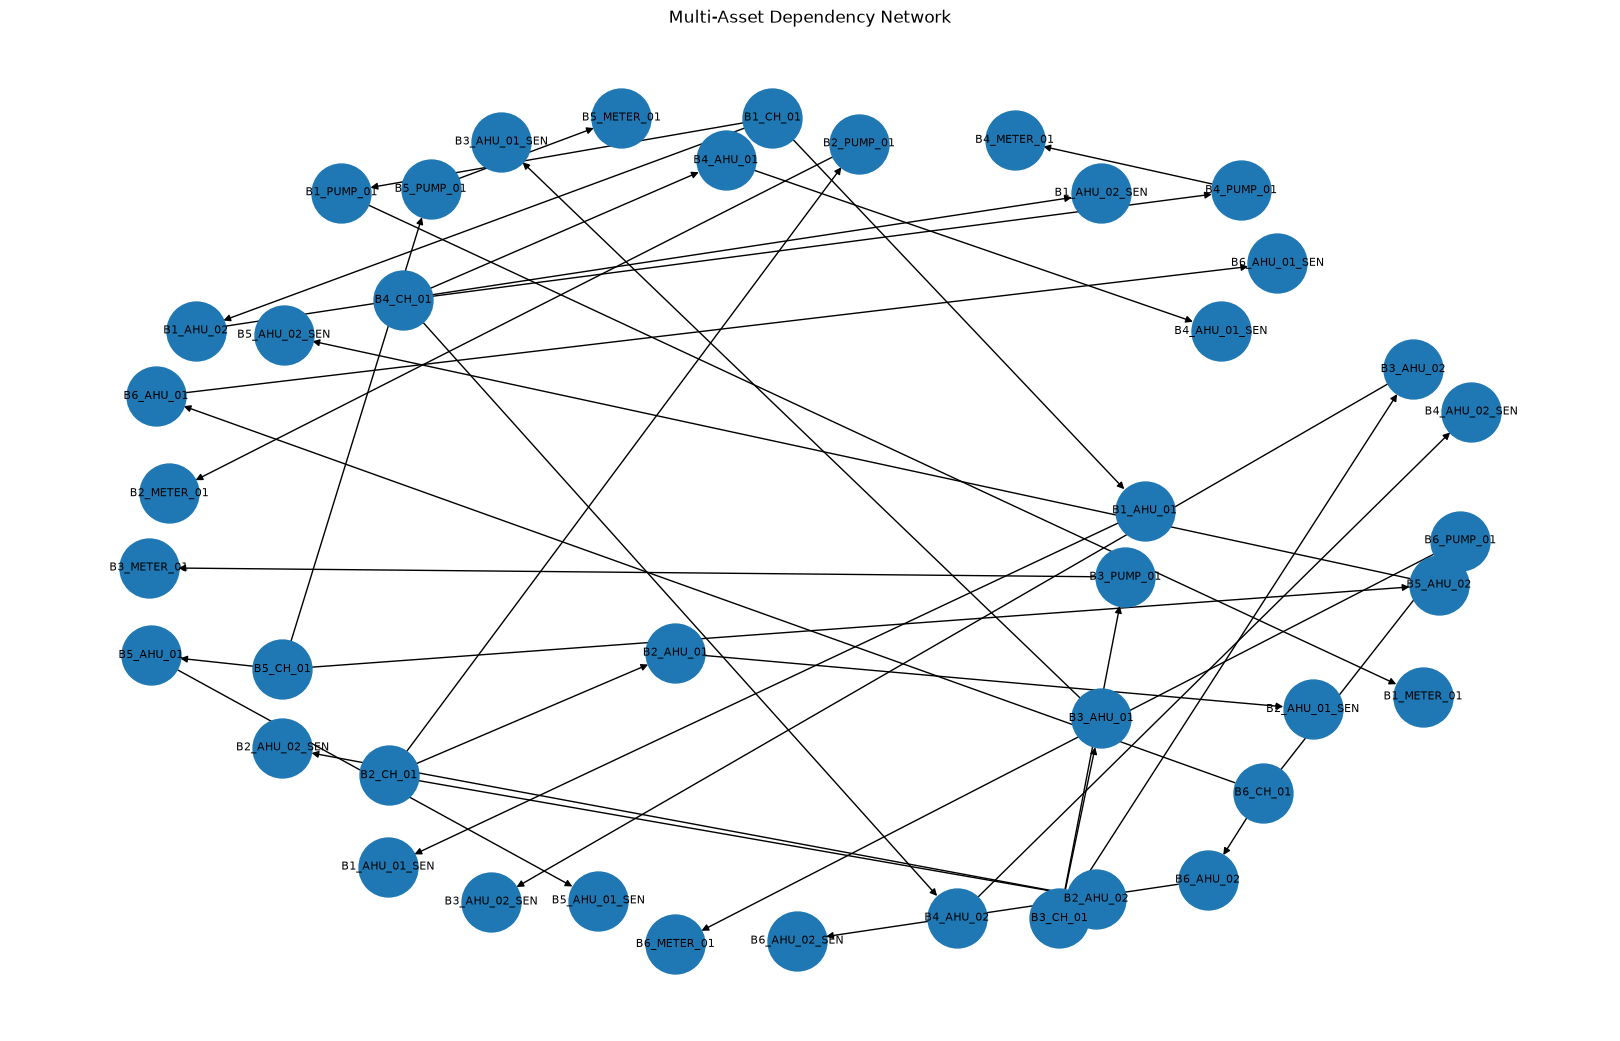

In [24]:
#Assest dependency network 
import matplotlib.pyplot as plt
import networkx as nx

plt.figure(figsize=(16, 10))

pos = nx.spring_layout(
    G,
    seed=42,
    k=1.5
)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1800,
    font_size=8,
    arrows=True
)

plt.title(
    "Multi-Asset Dependency Network"
)

plt.show()

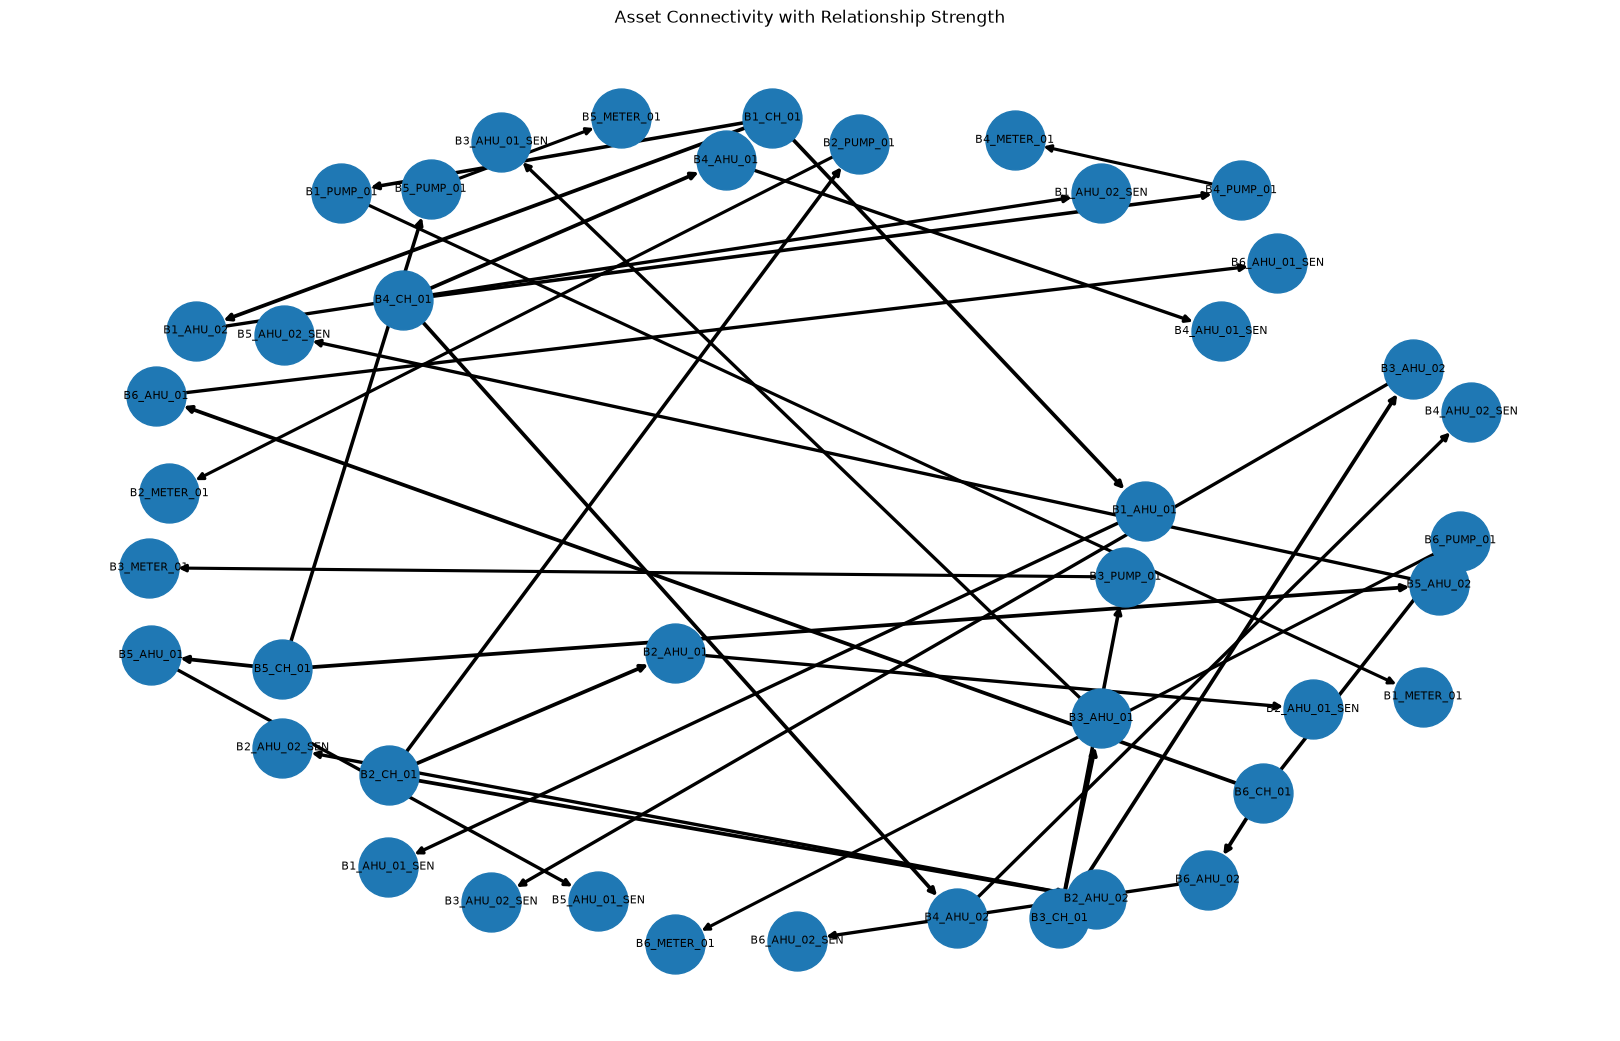

In [25]:
#visualiza relationship strength
plt.figure(figsize=(16, 10))

pos = nx.spring_layout(
    G,
    seed=42,
    k=1.5
)

edge_widths = [
    G[u][v]["relationship_strength"] * 3
    for u, v in G.edges()
]

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1800,
    font_size=8,
    width=edge_widths,
    arrows=True
)

plt.title(
    "Asset Connectivity with Relationship Strength"
)

plt.show()

In [26]:
#identify critical assets
critical_assets = (
    failure_impact_df[
        failure_impact_df["Impacted_Asset_Count"] > 0
    ]
    .sort_values(
        "Impacted_Asset_Count",
        ascending=False
    )
)

print(
    critical_assets[
        [
            "Failed_Asset",
            "Asset_Type",
            "Impacted_Asset_Count"
        ]
    ].head(10)
)

   Failed_Asset Asset_Type  Impacted_Asset_Count
0      B1_CH_01    Chiller                     6
7      B2_CH_01    Chiller                     6
28     B5_CH_01    Chiller                     6
35     B6_CH_01    Chiller                     6
21     B4_CH_01    Chiller                     6
14     B3_CH_01    Chiller                     6
1     B1_AHU_01        AHU                     1
3     B1_AHU_02        AHU                     1
8     B2_AHU_01        AHU                     1
5    B1_PUMP_01       Pump                     1


In [27]:
#export thefailure impact analysis
failure_impact_df.to_csv(
    "failure_impact_analysis.csv",
    index=False
)

print(
    "Failure impact analysis saved successfully."
)

Failure impact analysis saved successfully.


In [28]:
#export connectivity report
connectivity_report = connectivity.merge(
    asset_metadata[
        [
            "asset_id",
            "asset_name",
            "asset_type"
        ]
    ],
    left_on="source_asset_id",
    right_on="asset_id",
    how="left"
).rename(
    columns={
        "asset_name": "Source_Asset_Name",
        "asset_type": "Source_Asset_Type"
    }
).drop(
    columns=["asset_id"]
)

connectivity_report.to_csv(
    "asset_connectivity_report.csv",
    index=False
)

print(
    "Connectivity report saved successfully."
)

Connectivity report saved successfully.


summary

Built the Site → Asset → Parent-Child hierarchy using asset metadata.
Analyzed asset relationships using Supplies, Controls, and Monitors connections.
Identified connected, dependent, and isolated assets.
Performed failure impact analysis to identify downstream assets affected by critical asset failures.
Created a dependency network visualization to understand asset relationships.
Checked for missing values, duplicates, orphan assets, and invalid parent mappings.
The analysis can support root-cause analysis, maintenance prioritization, and failure mitigation